# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The BMW Global Sales Dataset](https://www.kaggle.com/datasets/velvetcrystal/bmw-global-sales-intelligence-2024-and-2025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/velvetcrystal/bmw-global-sales-intelligence-2024-and-2025/bmw_sales_2024_2025.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('bmw_sales_2024_2025.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,transaction_id,sale_date,sale_year,sale_month,sale_quarter,model,variant,segment,body_style,fuel_type,transmission,color,trim_line,optional_packages,options_cost_usd,msrp_usd,discount_percent,discount_amount_usd,final_sale_price_usd,financing_type,loan_term_months,region,country,sales_channel,customer_type,warranty_package,delivery_days,customer_satisfaction_score,is_repeat_customer,trade_in
0,BMW-2025-00001,2025-10-16,2025,10,Q4,2 Series,M240i,Compact,Hatchback,Electric (BEV),Automatic,Black Sapphire,M Sport,4,3380.44,47344.97,8.78,4156.89,43188.08,Lease,24.0,North America,USA,Dealership,Individual,5-Year Premium,86,4.4,False,True
1,BMW-2025-00002,2025-08-26,2025,8,Q3,4 Series,420i,Coupe,Sedan,Petrol,Steptronic Sport,Tanzanite Blue,Sport Line,2,3652.67,61068.13,10.39,6344.98,54723.15,Lease,24.0,China,China,Dealership,Individual,5-Year Premium,61,NaN,True,False
2,BMW-2024-00003,2024-03-21,2024,3,Q1,X3,M,SUV,SUV,Petrol,Automatic,Dravit Grey,Luxury Line,3,3817.67,58428.37,0.25,146.07,58282.30,Loan,24.0,Asia Pacific,South Korea,Online Direct,Corporate,2-Year Standard,49,4.6,False,True
3,BMW-2024-00004,2024-09-30,2024,9,Q3,X5,xDrive40i,SUV,SUV,Petrol,Automatic,Frozen Pure Grey,M Sport,5,6756.40,83810.05,2.20,1843.82,81966.23,Subscription,NaN,China,China,Dealership,Individual,2-Year Standard,10,NaN,False,False
4,BMW-2025-00005,2025-02-14,2025,2,Q1,4 Series,430i,Coupe,Sedan,Petrol,Manual,Mineral Grey,M Sport,4,4986.64,65315.77,5.18,3383.36,61932.41,Lease,48.0,Middle East,Qatar,Dealership,Corporate,3-Year Extended,77,4.4,False,False


## last Five row

In [4]:
df.tail()

,transaction_id,sale_date,sale_year,sale_month,sale_quarter,model,variant,segment,body_style,fuel_type,transmission,color,trim_line,optional_packages,options_cost_usd,msrp_usd,discount_percent,discount_amount_usd,final_sale_price_usd,financing_type,loan_term_months,region,country,sales_channel,customer_type,warranty_package,delivery_days,customer_satisfaction_score,is_repeat_customer,trade_in
9995,BMW-2025-09996,2025-12-05,2025,12,Q4,X3,xDrive30e,SUV,SUV,Petrol,Automatic,Black Sapphire,M Sport,3,3834.57,59415.64,10.21,6066.34,53349.30,Cash,NaN,Europe,Italy,Dealership,Individual,5-Year Premium,58,4.3,False,True
9996,BMW-2024-09997,2024-09-18,2024,9,Q3,i4,M50,EV,Sedan,Hybrid (PHEV),Automatic,Mineral Grey,Luxury Line,5,12078.48,63696.50,3.25,2070.14,61626.36,Cash,NaN,North America,Canada,Fleet/Corporate,Government,2-Year Standard,70,4.3,False,False
9997,BMW-2025-09998,2025-04-09,2025,4,Q2,X7,xDrive40i,SUV,SUV,Petrol,Automatic,Portimao Blue,Luxury Line,2,2034.82,102038.64,1.15,1173.44,100865.20,Subscription,NaN,Europe,Poland,Online Direct,Individual,3-Year Extended,58,NaN,True,True
9998,BMW-2024-09999,2024-06-26,2024,6,Q2,X3,xDrive30i,SUV,SUV,Diesel,Steptronic Sport,Carbon Black,M Sport,2,4618.69,56146.99,3.05,1712.48,54434.51,Lease,60.0,Europe,Netherlands,Dealership,Corporate,2-Year Standard,82,4.6,False,True
9999,BMW-2025-10000,2025-09-29,2025,9,Q3,i4,M50,EV,Sedan,Electric (BEV),Automatic,Portimao Blue,M Sport,5,8661.58,67881.09,7.01,4758.46,63122.63,Loan,72.0,North America,Mexico,Fleet/Corporate,Individual,5-Year Premium,84,4.5,False,False


## Shape of our dataset

In [5]:
df.shape

(10000, 30)

## List out all columns

In [6]:
df.columns

Index(['transaction_id', 'sale_date', 'sale_year', 'sale_month',
       'sale_quarter', 'model', 'variant', 'segment', 'body_style',
       'fuel_type', 'transmission', 'color', 'trim_line', 'optional_packages',
       'options_cost_usd', 'msrp_usd', 'discount_percent',
       'discount_amount_usd', 'final_sale_price_usd', 'financing_type',
       'loan_term_months', 'region', 'country', 'sales_channel',
       'customer_type', 'warranty_package', 'delivery_days',
       'customer_satisfaction_score', 'is_repeat_customer', 'trade_in'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

transaction_id                  object
sale_date                       object
sale_year                        int64
sale_month                       int64
sale_quarter                    object
model                           object
variant                         object
segment                         object
body_style                      object
fuel_type                       object
transmission                    object
color                           object
trim_line                       object
optional_packages                int64
options_cost_usd               float64
msrp_usd                       float64
discount_percent               float64
discount_amount_usd            float64
final_sale_price_usd           float64
financing_type                  object
loan_term_months               float64
region                          object
country                         object
sales_channel                   object
customer_type                   object
warranty_package         

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               10000 non-null  object 
 1   sale_date                    10000 non-null  object 
 2   sale_year                    10000 non-null  int64  
 3   sale_month                   10000 non-null  int64  
 4   sale_quarter                 10000 non-null  object 
 5   model                        10000 non-null  object 
 6   variant                      10000 non-null  object 
 7   segment                      10000 non-null  object 
 8   body_style                   10000 non-null  object 
 9   fuel_type                    10000 non-null  object 
 10  transmission                 10000 non-null  object 
 11  color                        10000 non-null  object 
 12  trim_line                    10000 non-null  object 
 13  optional_packages

## Check Null Value

In [9]:
df.isnull().sum()

transaction_id                    0
sale_date                         0
sale_year                         0
sale_month                        0
sale_quarter                      0
model                             0
variant                           0
segment                           0
body_style                        0
fuel_type                         0
transmission                      0
color                             0
trim_line                         0
optional_packages                 0
options_cost_usd                  0
msrp_usd                          0
discount_percent                  0
discount_amount_usd               0
final_sale_price_usd              0
financing_type                    0
loan_term_months               2720
region                            0
country                           0
sales_channel                     0
customer_type                     0
warranty_package                  0
delivery_days                     0
customer_satisfaction_score 

# Drop Null Value

In [10]:
df.drop(columns=['loan_term_months', 'customer_satisfaction_score'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,sale_year,sale_month,optional_packages,options_cost_usd,msrp_usd,discount_percent,discount_amount_usd,final_sale_price_usd,delivery_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2024.506800,6.519000,2.504900,4148.191505,66664.258043,6.005325,4001.147772,62663.110271,46.914700
std,0.499979,3.450019,1.705657,3192.830436,20539.062291,3.451911,2700.220021,19470.625265,25.274879
min,2024.000000,1.000000,0.000000,0.000000,31961.860000,0.000000,0.000000,29955.300000,3.000000
25%,2024.000000,4.000000,1.000000,1636.312500,50786.577500,3.060000,1862.892500,47781.485000,25.000000
50%,2025.000000,7.000000,3.000000,3795.215000,61967.975000,6.035000,3684.185000,58400.740000,47.000000
75%,2025.000000,10.000000,4.000000,6431.817500,77640.112500,8.980000,5619.302500,72974.722500,69.000000
max,2025.000000,12.000000,5.000000,12497.070000,134624.180000,12.000000,14557.910000,133399.100000,90.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

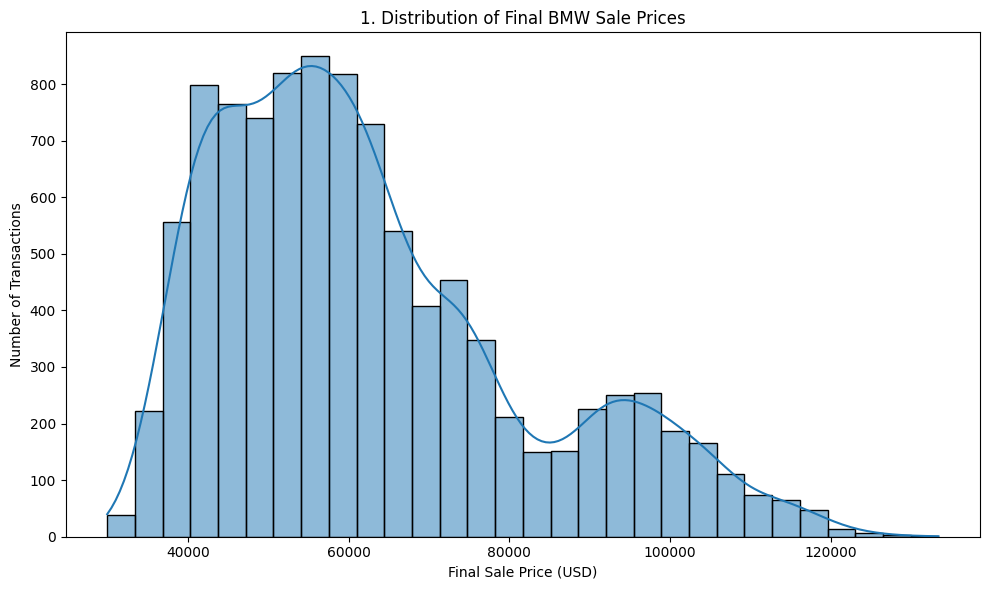

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='final_sale_price_usd', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Final BMW Sale Prices')
plt.xlabel('Final Sale Price (USD)')
plt.ylabel('Number of Transactions')
show_fig()
plot_no += 1

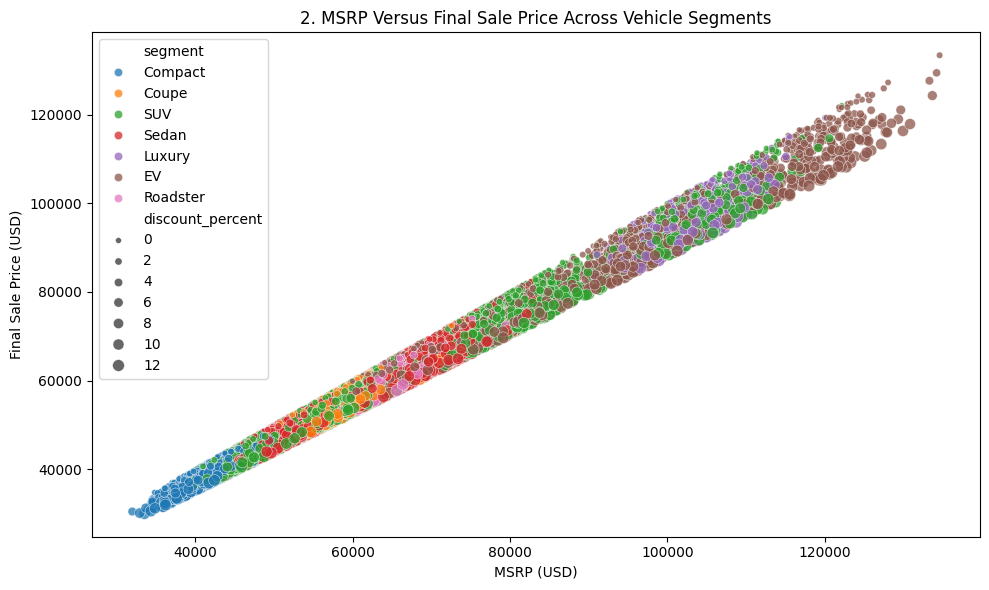

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='msrp_usd', y='final_sale_price_usd', hue='segment', size='discount_percent', alpha=0.75)
plt.title(f'{plot_no}. MSRP Versus Final Sale Price Across Vehicle Segments')
plt.xlabel('MSRP (USD)')
plt.ylabel('Final Sale Price (USD)')
show_fig()
plot_no += 1

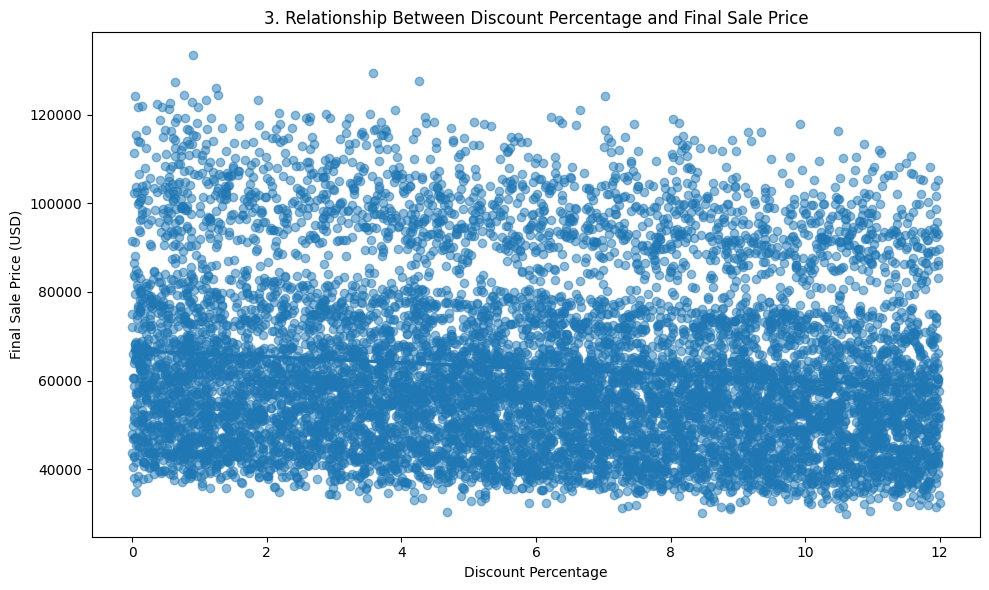

In [16]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='discount_percent', y='final_sale_price_usd', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Relationship Between Discount Percentage and Final Sale Price')
plt.xlabel('Discount Percentage')
plt.ylabel('Final Sale Price (USD)')
show_fig()
plot_no += 1

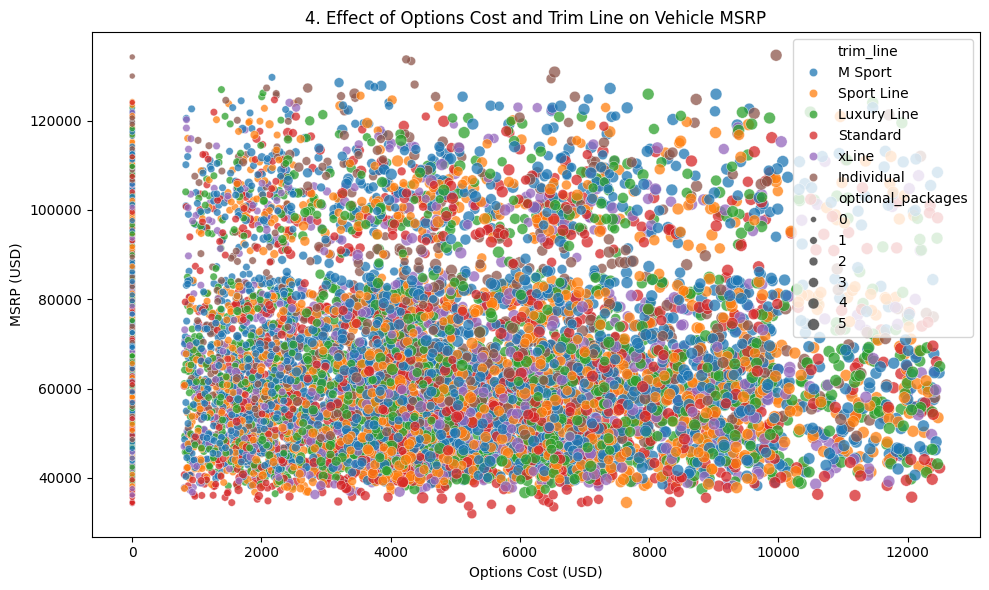

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='options_cost_usd', y='msrp_usd', hue='trim_line', size='optional_packages', alpha=0.75)
plt.title(f'{plot_no}. Effect of Options Cost and Trim Line on Vehicle MSRP')
plt.xlabel('Options Cost (USD)')
plt.ylabel('MSRP (USD)')
show_fig()
plot_no += 1

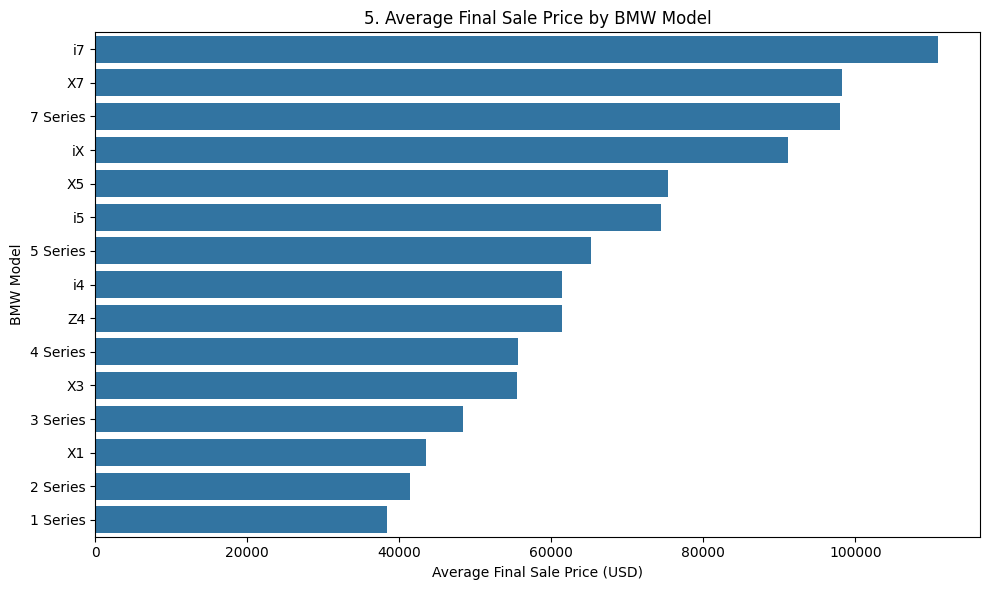

In [18]:
fig = plt.figure(figsize=(10,6))
model_price = df.groupby('model', as_index=False)['final_sale_price_usd'].mean().sort_values('final_sale_price_usd', ascending=False)
sns.barplot(data=model_price, x='final_sale_price_usd', y='model')
plt.title(f'{plot_no}. Average Final Sale Price by BMW Model')
plt.xlabel('Average Final Sale Price (USD)')
plt.ylabel('BMW Model')
show_fig()
plot_no += 1

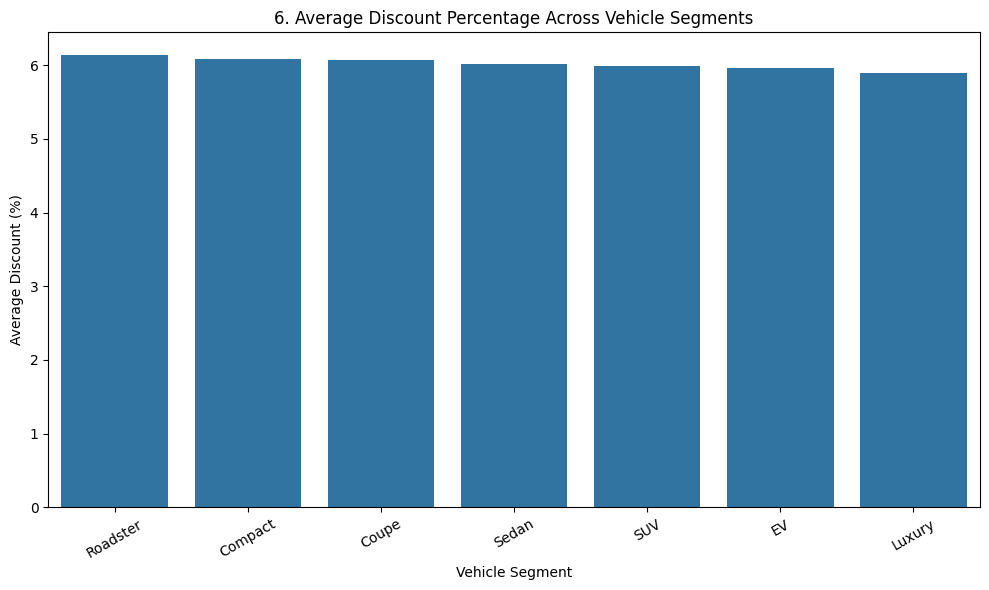

In [19]:
fig = plt.figure(figsize=(10,6))
segment_discount = df.groupby('segment', as_index=False)['discount_percent'].mean().sort_values('discount_percent', ascending=False)
sns.barplot(data=segment_discount, x='segment', y='discount_percent')
plt.title(f'{plot_no}. Average Discount Percentage Across Vehicle Segments')
plt.xlabel('Vehicle Segment')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

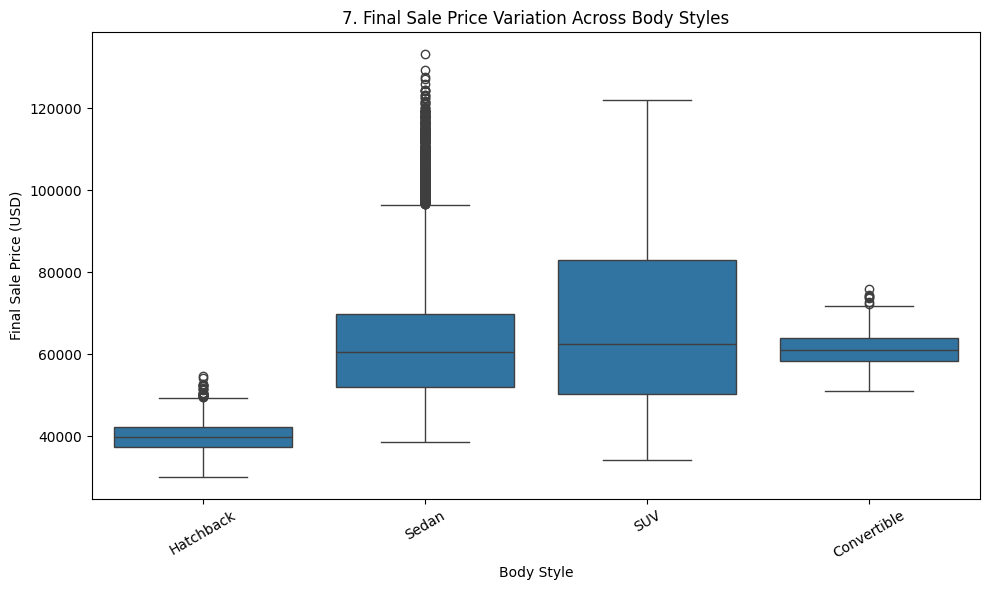

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='body_style', y='final_sale_price_usd')
plt.title(f'{plot_no}. Final Sale Price Variation Across Body Styles')
plt.xlabel('Body Style')
plt.ylabel('Final Sale Price (USD)')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

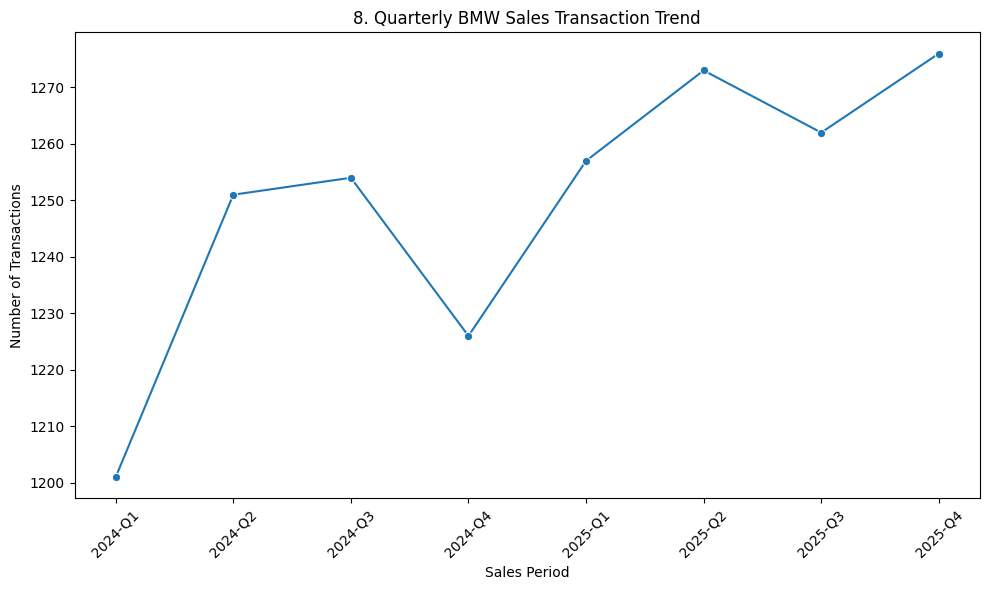

In [21]:
fig = plt.figure(figsize=(10,6))
quarterly_sales = df.groupby(['sale_year', 'sale_quarter']).size().reset_index(name='transactions')
quarterly_sales['period'] = quarterly_sales['sale_year'].astype(str) + '-' + quarterly_sales['sale_quarter']
sns.lineplot(data=quarterly_sales, x='period', y='transactions', marker='o')
plt.title(f'{plot_no}. Quarterly BMW Sales Transaction Trend')
plt.xlabel('Sales Period')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

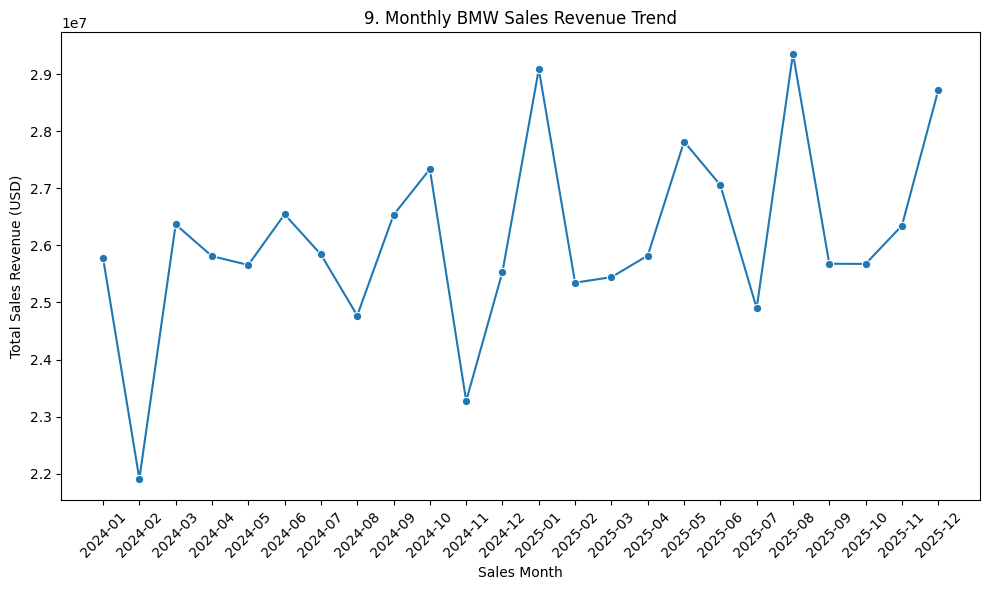

In [22]:
fig = plt.figure(figsize=(10,6))
monthly_revenue = df.groupby(['sale_year', 'sale_month'], as_index=False)['final_sale_price_usd'].sum()
monthly_revenue['period'] = monthly_revenue['sale_year'].astype(str) + '-' + monthly_revenue['sale_month'].astype(str).str.zfill(2)
sns.lineplot(data=monthly_revenue, x='period', y='final_sale_price_usd', marker='o')
plt.title(f'{plot_no}. Monthly BMW Sales Revenue Trend')
plt.xlabel('Sales Month')
plt.ylabel('Total Sales Revenue (USD)')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

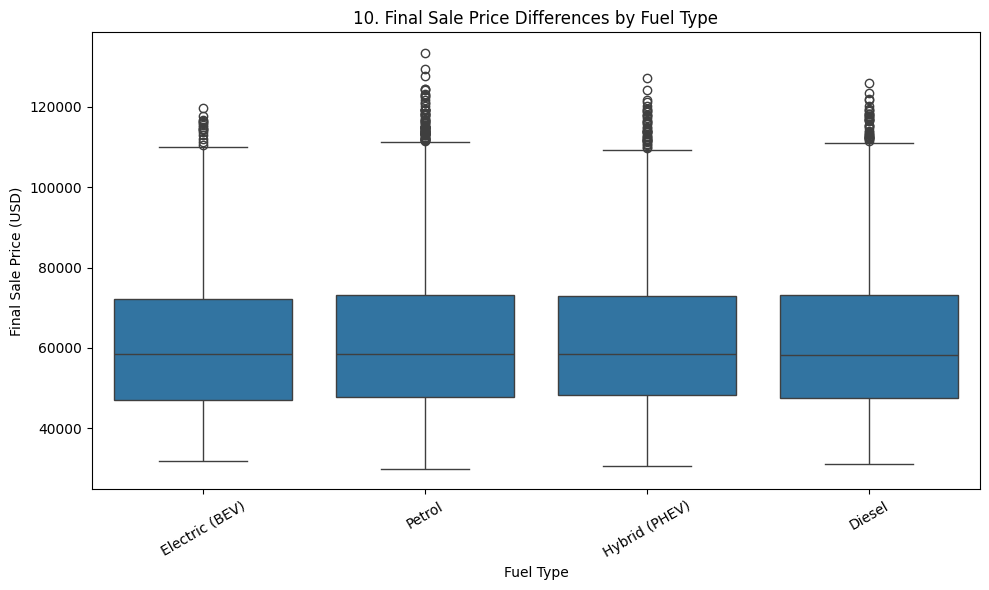

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fuel_type', y='final_sale_price_usd')
plt.title(f'{plot_no}. Final Sale Price Differences by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Final Sale Price (USD)')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

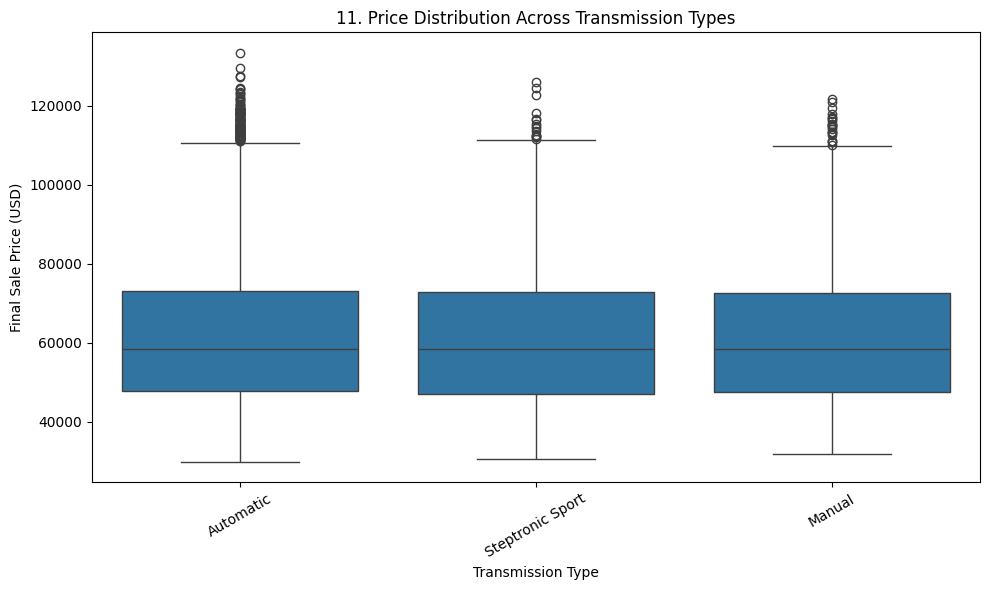

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='transmission', y='final_sale_price_usd')
plt.title(f'{plot_no}. Price Distribution Across Transmission Types')
plt.xlabel('Transmission Type')
plt.ylabel('Final Sale Price (USD)')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

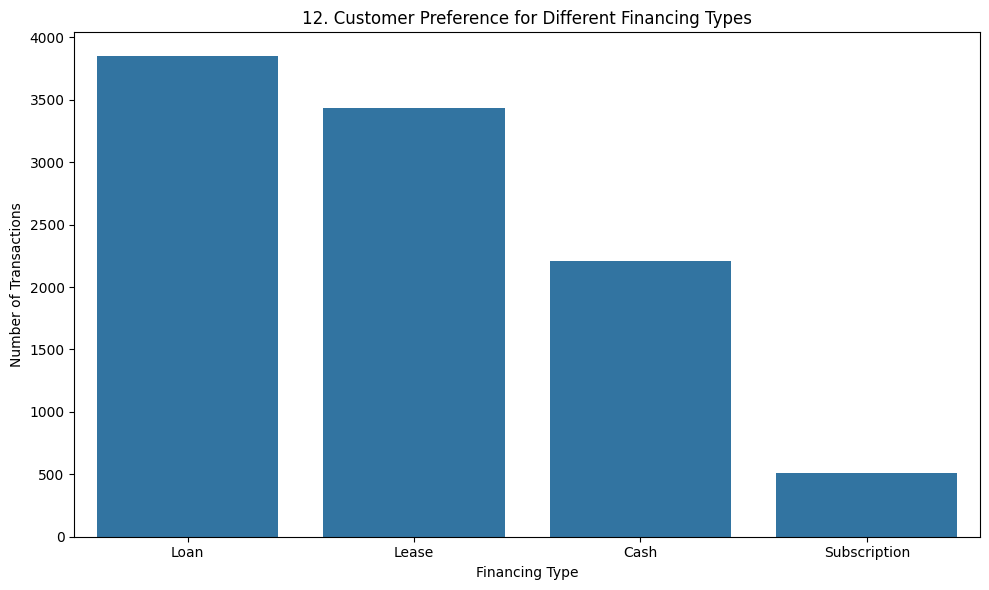

In [25]:
fig = plt.figure(figsize=(10,6))
financing_count = df['financing_type'].value_counts().reset_index()
financing_count.columns = ['financing_type', 'transactions']
sns.barplot(data=financing_count, x='financing_type', y='transactions')
plt.title(f'{plot_no}. Customer Preference for Different Financing Types')
plt.xlabel('Financing Type')
plt.ylabel('Number of Transactions')
show_fig()
plot_no += 1

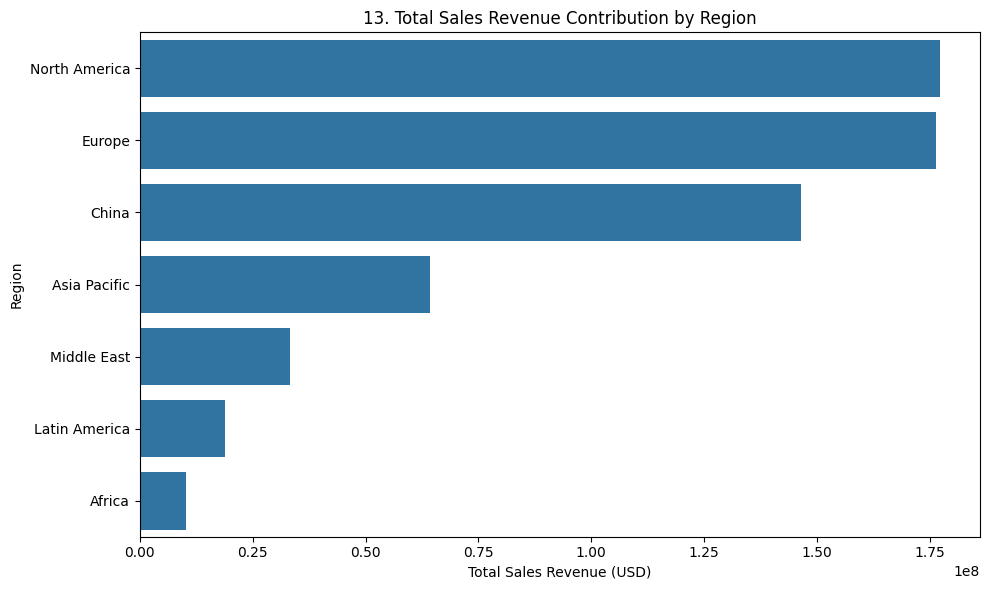

In [26]:
fig = plt.figure(figsize=(10,6))
region_revenue = df.groupby('region', as_index=False)['final_sale_price_usd'].sum().sort_values('final_sale_price_usd', ascending=False)
sns.barplot(data=region_revenue, x='final_sale_price_usd', y='region')
plt.title(f'{plot_no}. Total Sales Revenue Contribution by Region')
plt.xlabel('Total Sales Revenue (USD)')
plt.ylabel('Region')
show_fig()
plot_no += 1

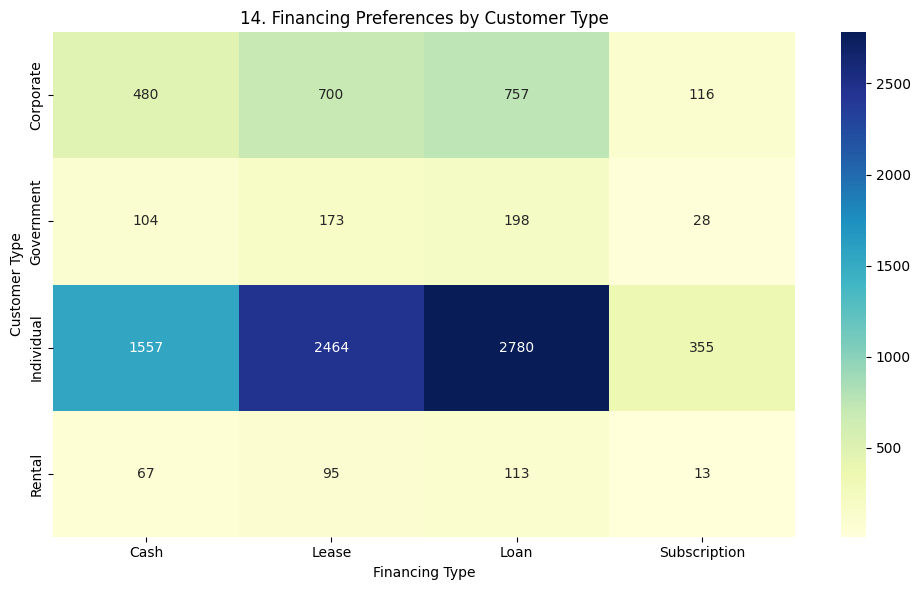

In [27]:
fig = plt.figure(figsize=(10,6))
financing_customer = pd.crosstab(df['customer_type'], df['financing_type'])
sns.heatmap(financing_customer, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'{plot_no}. Financing Preferences by Customer Type')
plt.xlabel('Financing Type')
plt.ylabel('Customer Type')
show_fig()
plot_no += 1

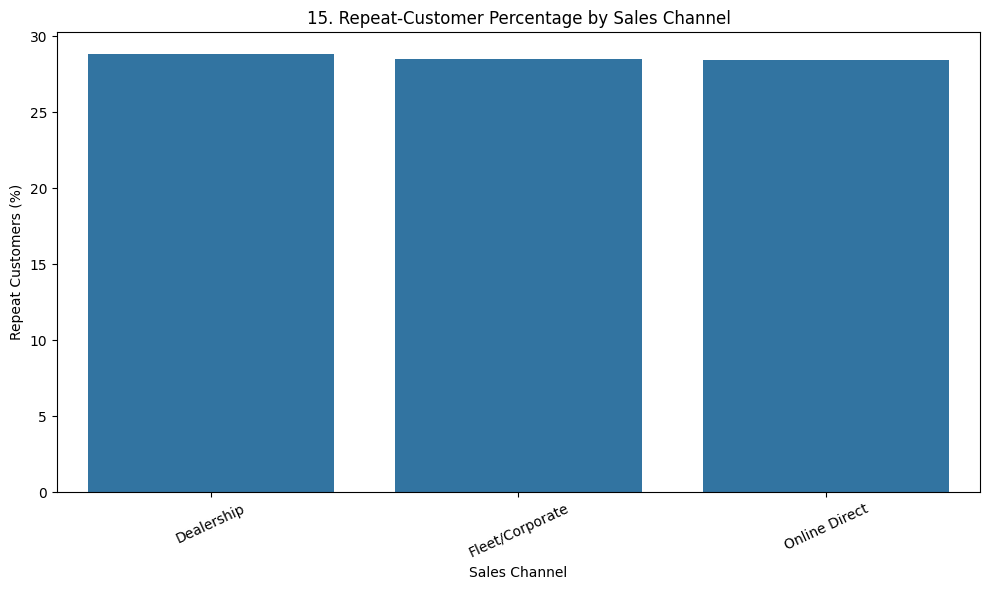

In [28]:
fig = plt.figure(figsize=(10,6))
repeat_channel = df.groupby('sales_channel')['is_repeat_customer'].mean().mul(100).reset_index()
sns.barplot(data=repeat_channel, x='sales_channel', y='is_repeat_customer')
plt.title(f'{plot_no}. Repeat-Customer Percentage by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Repeat Customers (%)')
plt.xticks(rotation=25)
show_fig()
plot_no += 1

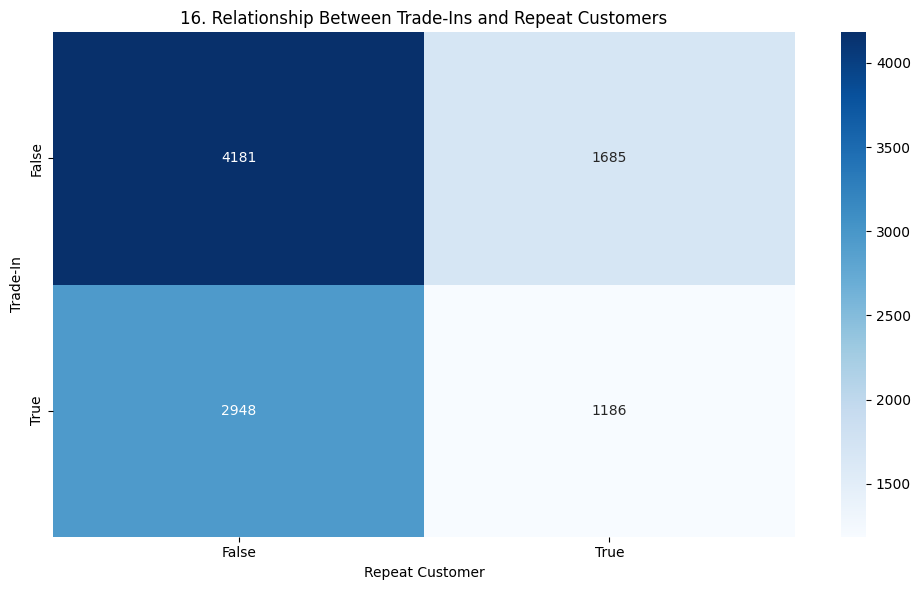

In [29]:
fig = plt.figure(figsize=(10,6))
trade_repeat = pd.crosstab(df['trade_in'], df['is_repeat_customer'])
sns.heatmap(trade_repeat, annot=True, fmt='d', cmap='Blues')
plt.title(f'{plot_no}. Relationship Between Trade-Ins and Repeat Customers')
plt.xlabel('Repeat Customer')
plt.ylabel('Trade-In')
show_fig()
plot_no += 1

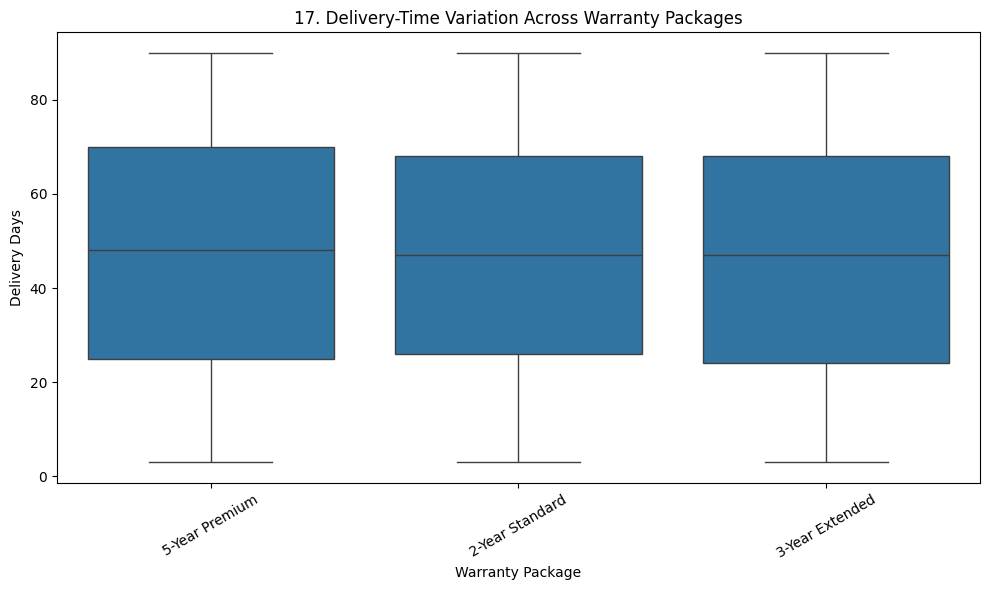

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='warranty_package', y='delivery_days')
plt.title(f'{plot_no}. Delivery-Time Variation Across Warranty Packages')
plt.xlabel('Warranty Package')
plt.ylabel('Delivery Days')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

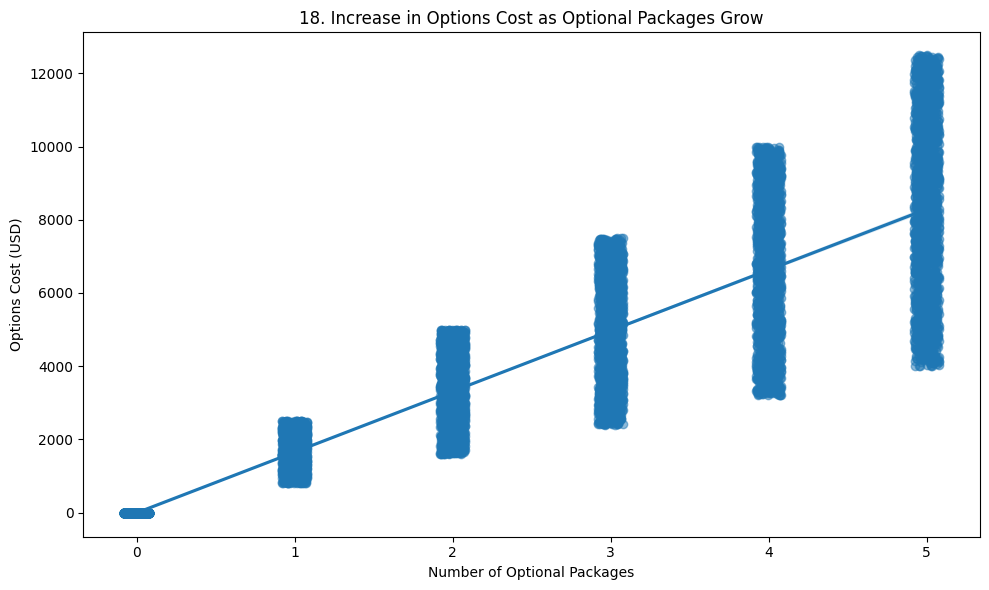

In [31]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='optional_packages', y='options_cost_usd', x_jitter=0.08, scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Increase in Options Cost as Optional Packages Grow')
plt.xlabel('Number of Optional Packages')
plt.ylabel('Options Cost (USD)')
show_fig()
plot_no += 1

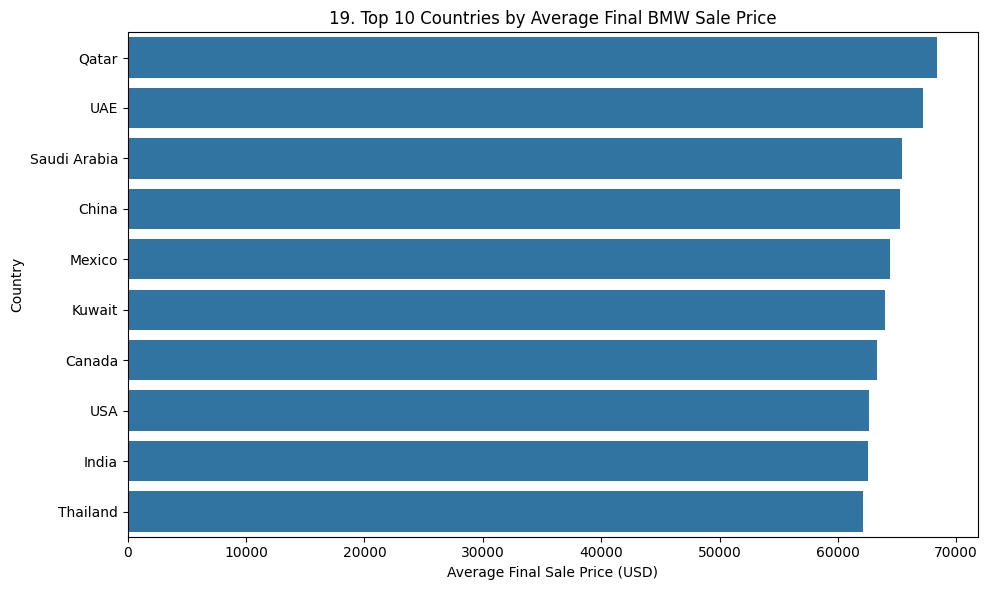

In [32]:
fig = plt.figure(figsize=(10,6))
country_price = df.groupby('country', as_index=False)['final_sale_price_usd'].mean().nlargest(10, 'final_sale_price_usd')
sns.barplot(data=country_price, x='final_sale_price_usd', y='country')
plt.title(f'{plot_no}. Top 10 Countries by Average Final BMW Sale Price')
plt.xlabel('Average Final Sale Price (USD)')
plt.ylabel('Country')
show_fig()
plot_no += 1

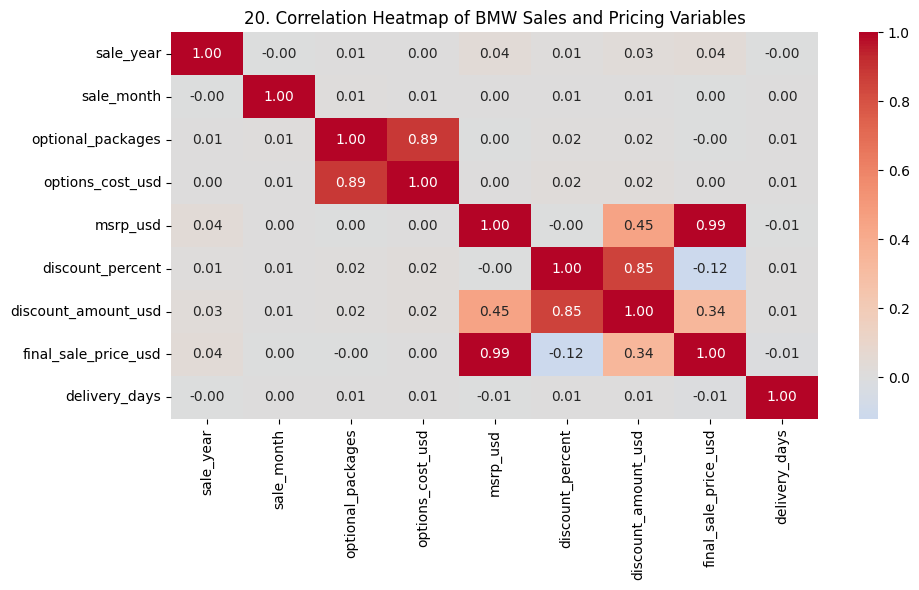

In [33]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of BMW Sales and Pricing Variables')
show_fig()
plot_no += 1

# Model Training

## convert sale date into datetime

In [35]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

## extract useful date features

In [36]:
df['sale_day'] = df['sale_date'].dt.day
df['sale_dayofweek'] = df['sale_date'].dt.dayofweek

## select prediction target

In [37]:
target = 'final_sale_price_usd'

## create input features

In [38]:
X = df.drop(columns=[target, 'transaction_id', 'sale_date'])

## create target values

In [39]:
y = df[target]

## identify numerical columns

In [40]:
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

## identify categorical columns

In [41]:
cat_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns

## create numerical preprocessing

In [42]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## create categorical preprocessing

In [43]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## combine preprocessing steps

In [44]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## create gradient boosting model

In [45]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

## split data into training and testing sets

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## train the model

In [47]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['sale_year', 'sale_month', 'optional_packages', 'options_cost_usd',
       'msrp_usd', 'discount_percent', 'discount_amount_usd', 'delivery_days',
       'sale_day', 'sale_dayofweek'],
      dtype='object')),
                                                 ('c...
                                                  Index(['sale_quarter', 'model', 'variant', 'segment', 'body_style',
       'fuel_type', 'transmission', 'color', 'trim_line', 'financing_type',
       'region', 'country', 'sales_channel', 'customer_type',
       'warranty_package', 'is_repeat_customer', 'trade_in'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           min_samples_leaf=3,
                                           min_samples_split=5,
                                           n_estimators=300,
                                           random_state=42))])

## generate predictions

In [48]:
y_pred = model.predict(X_test)

## calculate model scores

In [49]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## print model performance

In [50]:
print(f'Model Accuracy (R²): {r2 * 100:.2f}%')
print(f'Mean Absolute Error: ${mae:,.2f}')
print(f'Root Mean Squared Error: ${rmse:,.2f}')

Model Accuracy (R²): 99.98%
Mean Absolute Error: $176.72
Root Mean Squared Error: $263.54


## create actual versus predicted chart

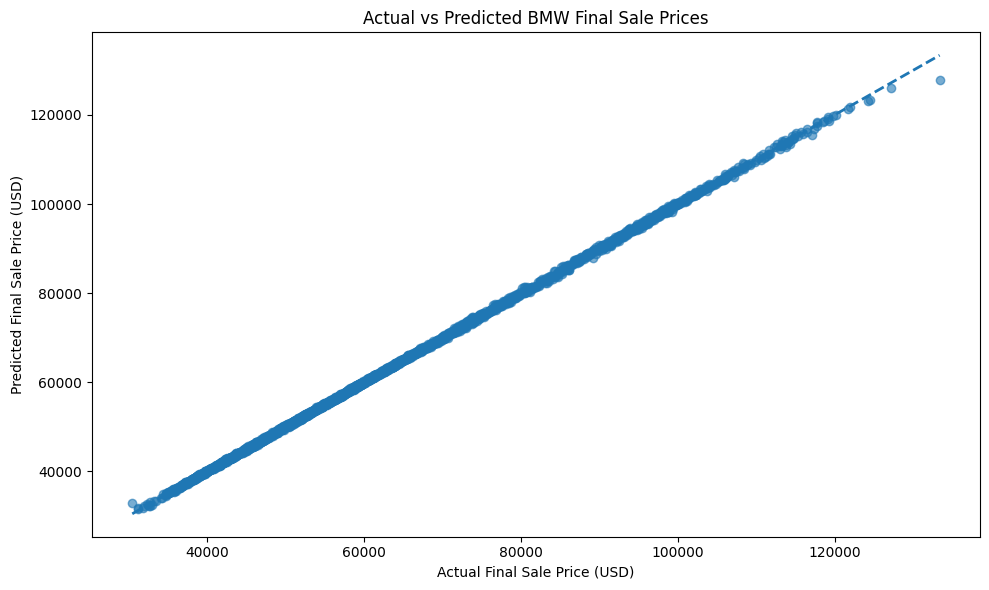

In [51]:
minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle='--',
    linewidth=2
)
plt.xlabel('Actual Final Sale Price (USD)')
plt.ylabel('Predicted Final Sale Price (USD)')
plt.title('Actual vs Predicted BMW Final Sale Prices')
plt.tight_layout()
plt.show()